# IMC Prosperity Log Analyzer

Parse and visualize a submission log file. Set the `LOG_PATH` and `PRODUCT` below, then run all cells.

**Outputs:**
- Per-timestamp master table: FV, best bid/ask, position, orders placed, actual fills, PnL
- Price + FV overlay plot with order markers
- Position and PnL over time
- Fill rate analysis
- Filter for 'interesting' ticks (fills, position extremes, etc)

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO
from pathlib import Path
import prosperity4

# === CONFIG ===
REPO_ROOT = Path(prosperity4.__file__).parents[1]
DATA_FOLDER = REPO_ROOT / "prosperity4" / "round2" / "logs"
LOG_PATH = DATA_FOLDER / "363917.log.txt"
# "INTARIAN_PEPPER_ROOT"
PRODUCT = "ASH_COATED_OSMIUM"

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

## 1. Load the log file

In [2]:
with open(LOG_PATH) as f:
    raw = json.load(f)

print(f"Submission ID: {raw['submissionId']}")
print(f"Lambda log entries: {len(raw['logs'])}")
print(f"Trade history entries: {len(raw['tradeHistory'])}")
print(f"Activity log size: {len(raw['activitiesLog'])} chars")

Submission ID: e0476da0-0b77-485c-ae25-7f2ba8bb3290
Lambda log entries: 10000
Trade history entries: 914
Activity log size: 1574358 chars


## 2. Parse the activities log (market state)

One row per product per timestamp. Gives us best bid/ask/volume, mid price, running PnL.

In [4]:
activities = pd.read_csv(StringIO(raw["activitiesLog"]), sep=";")
activities = activities[activities["product"] == PRODUCT].copy()
activities = activities.sort_values("timestamp").reset_index(drop=True)
print(f"Activity rows for {PRODUCT}: {len(activities)}")
activities.head()

Activity rows for ASH_COATED_OSMIUM: 10000


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,2,0,ASH_COATED_OSMIUM,9963.0,13.0,9960.0,21.0,NaN,NaN,9979.0,13.0,9981.0,21.0,NaN,NaN,9971.0,0.000000
1,2,100,ASH_COATED_OSMIUM,9963.0,15.0,9960.0,26.0,NaN,NaN,9979.0,15.0,9981.0,26.0,NaN,NaN,9971.0,40.296875
2,2,200,ASH_COATED_OSMIUM,9962.0,15.0,NaN,NaN,NaN,NaN,9978.0,15.0,NaN,NaN,NaN,NaN,9970.0,37.765625
3,2,300,ASH_COATED_OSMIUM,9962.0,12.0,9960.0,27.0,NaN,NaN,9978.0,12.0,9980.0,27.0,NaN,NaN,9970.0,35.898438
4,2,400,ASH_COATED_OSMIUM,9962.0,12.0,NaN,NaN,NaN,NaN,9978.0,12.0,9981.0,25.0,NaN,NaN,9970.0,37.328125


## 3. Parse the lambda logs (your `self.log()` output)

Extracts whatever you printed inside `get_orders()` — FV, POS, SPREAD, and BUY/SELL entries. Supports both old format (single dict, overwriting) and new list-based format.

In [5]:
def parse_lambda_logs(raw_logs, product):
    rows = []
    for entry in raw_logs:
        lamb = entry.get("lambdaLog", "")
        if not lamb:
            continue
        try:
            parsed = json.loads(lamb)
        except json.JSONDecodeError:
            continue

        prod = parsed.get(product, {})
        row = {"timestamp": entry["timestamp"]}

        # Copy all scalar fields
        for k, v in prod.items():
            if k in ("BUY", "SELL", "BUYS", "SELLS"):
                continue
            row[k] = v

        # Orders placed — support list or single-dict formats
        buys_field = prod.get("BUYS")
        sells_field = prod.get("SELLS")
        buy_field = prod.get("BUY")
        sell_field = prod.get("SELL")

        placed_buys = buys_field if isinstance(buys_field, list) else ([buy_field] if buy_field else [])
        placed_sells = sells_field if isinstance(sells_field, list) else ([sell_field] if sell_field else [])

        row["placed_buys"] = placed_buys
        row["placed_sells"] = placed_sells
        row["n_buys_placed"] = len(placed_buys)
        row["n_sells_placed"] = len(placed_sells)
        row["total_buy_vol"] = sum(b.get("v", 0) for b in placed_buys)
        row["total_sell_vol"] = sum(s.get("v", 0) for s in placed_sells)

        rows.append(row)

    return pd.DataFrame(rows)

lambda_df = parse_lambda_logs(raw["logs"], PRODUCT)
print(f"Lambda log rows: {len(lambda_df)}")
lambda_df.head()

Lambda log rows: 10000


,timestamp,POS,FV,BBID,BASK,SPREAD,placed_buys,placed_sells,n_buys_placed,n_sells_placed,total_buy_vol,total_sell_vol
0,0,0.0,9971.00,9963.0,9979.0,16.0,"[{'p': 9964, 'v': 80}]","[{'p': 9978, 'v': 80}]",1,1,80,80
1,100,6.0,9971.00,9963.0,9979.0,16.0,"[{'p': 9964, 'v': 74}]","[{'p': 9978, 'v': 86}]",1,1,74,86
2,200,6.0,9970.82,9962.0,9978.0,16.0,"[{'p': 9963, 'v': 74}]","[{'p': 9977, 'v': 86}]",1,1,74,86
3,300,6.0,9970.69,9962.0,9978.0,16.0,"[{'p': 9963, 'v': 74}]","[{'p': 9977, 'v': 86}]",1,1,74,86
4,400,6.0,9970.58,9962.0,9978.0,16.0,"[{'p': 9963, 'v': 74}]","[{'p': 9977, 'v': 86}]",1,1,74,86


## 4. Parse the trade history (actual fills)

`SUBMISSION` as buyer = we bought. `SUBMISSION` as seller = we sold. Others = bot-to-bot trades.

In [6]:
trades = pd.DataFrame(raw["tradeHistory"])
trades = trades[trades["symbol"] == PRODUCT].copy()

def classify(row):
    if row["buyer"] == "SUBMISSION":
        return "our_buy"
    elif row["seller"] == "SUBMISSION":
        return "our_sell"
    else:
        return "other"

trades["kind"] = trades.apply(classify, axis=1)
trades["signed_qty"] = trades.apply(
    lambda r: r["quantity"] if r["kind"] == "our_buy" else (-r["quantity"] if r["kind"] == "our_sell" else 0),
    axis=1
)
print(f"Total trades: {len(trades)}")
print(trades["kind"].value_counts())
trades.head()

Total trades: 491
kind
our_sell    217
our_buy     216
other        58
Name: count, dtype: int64


,timestamp,buyer,seller,symbol,currency,price,quantity,kind,signed_qty
0,0,SUBMISSION,,ASH_COATED_OSMIUM,XIRECS,9964.0,6,our_buy,6
7,3600,,SUBMISSION,ASH_COATED_OSMIUM,XIRECS,9977.0,3,our_sell,-3
8,4200,,SUBMISSION,ASH_COATED_OSMIUM,XIRECS,9977.0,2,our_sell,-2
11,9100,,,ASH_COATED_OSMIUM,XIRECS,9968.0,4,other,0
12,9600,SUBMISSION,,ASH_COATED_OSMIUM,XIRECS,9963.0,6,our_buy,6


In [7]:
# Aggregate our fills per timestamp
our_trades = trades[trades["kind"].isin(["our_buy", "our_sell"])].copy()

fills_per_ts = (
    our_trades.groupby(["timestamp", "kind"])
    .agg(price_avg=("price", "mean"), qty_total=("quantity", "sum"))
    .unstack("kind", fill_value=0)
)
fills_per_ts.columns = [f"{a}_{b}" for a, b in fills_per_ts.columns]
fills_per_ts = fills_per_ts.reset_index()
print(f"Timestamps with fills: {len(fills_per_ts)}")
fills_per_ts.head()

Timestamps with fills: 429


,timestamp,price_avg_our_buy,price_avg_our_sell,qty_total_our_buy,qty_total_our_sell
0,0,9964.0,0.0,6,0
1,3600,0.0,9977.0,0,3
2,4200,0.0,9977.0,0,2
3,9600,9963.0,0.0,6,0
4,10000,9964.0,0.0,8,0


## 5. Build the master table

One row per timestamp: market state + your logged values + placed orders + actual fills.

In [9]:
df = activities[["timestamp", "bid_price_1", "bid_volume_1", "ask_price_1", "ask_volume_1",
                 "mid_price", "profit_and_loss"]].copy()
df = df.rename(columns={"bid_price_1": "best_bid", "ask_price_1": "best_ask",
                        "bid_volume_1": "bid_vol", "ask_volume_1": "ask_vol",
                        "profit_and_loss": "pnl"})

df = df.merge(lambda_df, on="timestamp", how="left")
df = df.merge(fills_per_ts, on="timestamp", how="left")

for col in ["qty_total_our_buy", "qty_total_our_sell"]:
    if col in df.columns:
        df[col] = df[col].fillna(0)

df["spread"] = df["best_ask"] - df["best_bid"]

print(f"Master table shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
display(df.head(10))

Master table shape: (10000, 23)
Columns: ['timestamp', 'best_bid', 'bid_vol', 'best_ask', 'ask_vol', 'mid_price', 'pnl', 'POS', 'FV', 'BBID', 'BASK', 'SPREAD', 'placed_buys', 'placed_sells', 'n_buys_placed', 'n_sells_placed', 'total_buy_vol', 'total_sell_vol', 'price_avg_our_buy', 'price_avg_our_sell', 'qty_total_our_buy', 'qty_total_our_sell', 'spread']


,timestamp,best_bid,bid_vol,best_ask,ask_vol,mid_price,pnl,POS,FV,BBID,BASK,SPREAD,placed_buys,placed_sells,n_buys_placed,n_sells_placed,total_buy_vol,total_sell_vol,price_avg_our_buy,price_avg_our_sell,qty_total_our_buy,qty_total_our_sell,spread
0,0,9963.0,13.0,9979.0,13.0,9971.0,0.000000,0.0,9971.00,9963.0,9979.0,16.0,"[{'p': 9964, 'v': 80}]","[{'p': 9978, 'v': 80}]",1,1,80,80,9964.0,0.0,6.0,0.0,16.0
1,100,9963.0,15.0,9979.0,15.0,9971.0,40.296875,6.0,9971.00,9963.0,9979.0,16.0,"[{'p': 9964, 'v': 74}]","[{'p': 9978, 'v': 86}]",1,1,74,86,NaN,NaN,0.0,0.0,16.0
2,200,9962.0,15.0,9978.0,15.0,9970.0,37.765625,6.0,9970.82,9962.0,9978.0,16.0,"[{'p': 9963, 'v': 74}]","[{'p': 9977, 'v': 86}]",1,1,74,86,NaN,NaN,0.0,0.0,16.0
3,300,9962.0,12.0,9978.0,12.0,9970.0,35.898438,6.0,9970.69,9962.0,9978.0,16.0,"[{'p': 9963, 'v': 74}]","[{'p': 9977, 'v': 86}]",1,1,74,86,NaN,NaN,0.0,0.0,16.0
4,400,9962.0,12.0,9978.0,12.0,9970.0,37.328125,6.0,9970.58,9962.0,9978.0,16.0,"[{'p': 9963, 'v': 74}]","[{'p': 9977, 'v': 86}]",1,1,74,86,NaN,NaN,0.0,0.0,16.0
5,500,9962.0,11.0,9978.0,11.0,9970.0,35.234375,6.0,9970.50,9962.0,9978.0,16.0,"[{'p': 9963, 'v': 74}]","[{'p': 9977, 'v': 86}]",1,1,74,86,NaN,NaN,0.0,0.0,16.0
6,600,NaN,NaN,9981.0,25.0,9981.0,37.195312,6.0,9971.01,NaN,9981.0,NaN,"[{'p': 9963, 'v': 74}]","[{'p': 9980, 'v': 86}]",1,1,74,86,NaN,NaN,0.0,0.0,NaN
7,700,9963.0,11.0,9979.0,11.0,9971.0,39.835938,6.0,9971.25,9963.0,9979.0,16.0,"[{'p': 9964, 'v': 74}]","[{'p': 9978, 'v': 86}]",1,1,74,86,NaN,NaN,0.0,0.0,16.0
8,800,9963.0,12.0,9979.0,12.0,9971.0,41.894531,6.0,9971.37,9963.0,9979.0,16.0,"[{'p': 9964, 'v': 74}]","[{'p': 9978, 'v': 86}]",1,1,74,86,NaN,NaN,0.0,0.0,16.0
9,900,9963.0,12.0,9982.0,21.0,9972.5,43.406250,6.0,9971.46,9963.0,9982.0,19.0,"[{'p': 9964, 'v': 74}]","[{'p': 9981, 'v': 86}]",1,1,74,86,NaN,NaN,0.0,0.0,19.0


## 6. Main analysis table

Key fields per timestamp. Orders shown as `volume@price`.

In [10]:
def format_orders(orders):
    if not isinstance(orders, list) or len(orders) == 0:
        return ""
    return ", ".join(f"{o.get('v', '?')}@{o.get('p', '?')}" for o in orders)

display_df = df.copy()
display_df["buys"] = display_df["placed_buys"].apply(format_orders)
display_df["sells"] = display_df["placed_sells"].apply(format_orders)

available = set(display_df.columns)
want = ["timestamp", "best_bid", "best_ask", "spread", "mid_price"]
for opt in ["FV", "POS", "ZSCORE", "SKEW_SHIFT"]:
    if opt in available:
        want.append(opt)
want += ["buys", "sells"]
if "qty_total_our_buy" in available:
    want += ["qty_total_our_buy", "qty_total_our_sell"]
want += ["pnl"]

final_cols = [c for c in want if c in available]
display_df[final_cols].head(10)

,timestamp,best_bid,best_ask,spread,mid_price,FV,POS,buys,sells,qty_total_our_buy,qty_total_our_sell,pnl
0,0,9963.0,9979.0,16.0,9971.0,9971.00,0.0,80@9964,80@9978,6.0,0.0,0.000000
1,100,9963.0,9979.0,16.0,9971.0,9971.00,6.0,74@9964,86@9978,0.0,0.0,40.296875
2,200,9962.0,9978.0,16.0,9970.0,9970.82,6.0,74@9963,86@9977,0.0,0.0,37.765625
3,300,9962.0,9978.0,16.0,9970.0,9970.69,6.0,74@9963,86@9977,0.0,0.0,35.898438
4,400,9962.0,9978.0,16.0,9970.0,9970.58,6.0,74@9963,86@9977,0.0,0.0,37.328125
5,500,9962.0,9978.0,16.0,9970.0,9970.50,6.0,74@9963,86@9977,0.0,0.0,35.234375
6,600,NaN,9981.0,NaN,9981.0,9971.01,6.0,74@9963,86@9980,0.0,0.0,37.195312
7,700,9963.0,9979.0,16.0,9971.0,9971.25,6.0,74@9964,86@9978,0.0,0.0,39.835938
8,800,9963.0,9979.0,16.0,9971.0,9971.37,6.0,74@9964,86@9978,0.0,0.0,41.894531
9,900,9963.0,9982.0,19.0,9972.5,9971.46,6.0,74@9964,86@9981,0.0,0.0,43.406250


In [28]:
# Export to CSV for offline analysis
# df.to_csv("log_analysis.csv", index=False)
# print("Saved to log_analysis.csv")

## 7. Price, FV, and fills overlay

Mid price + best bid/ask + your FV estimate. Green triangles = our buys. Red triangles = our sells.

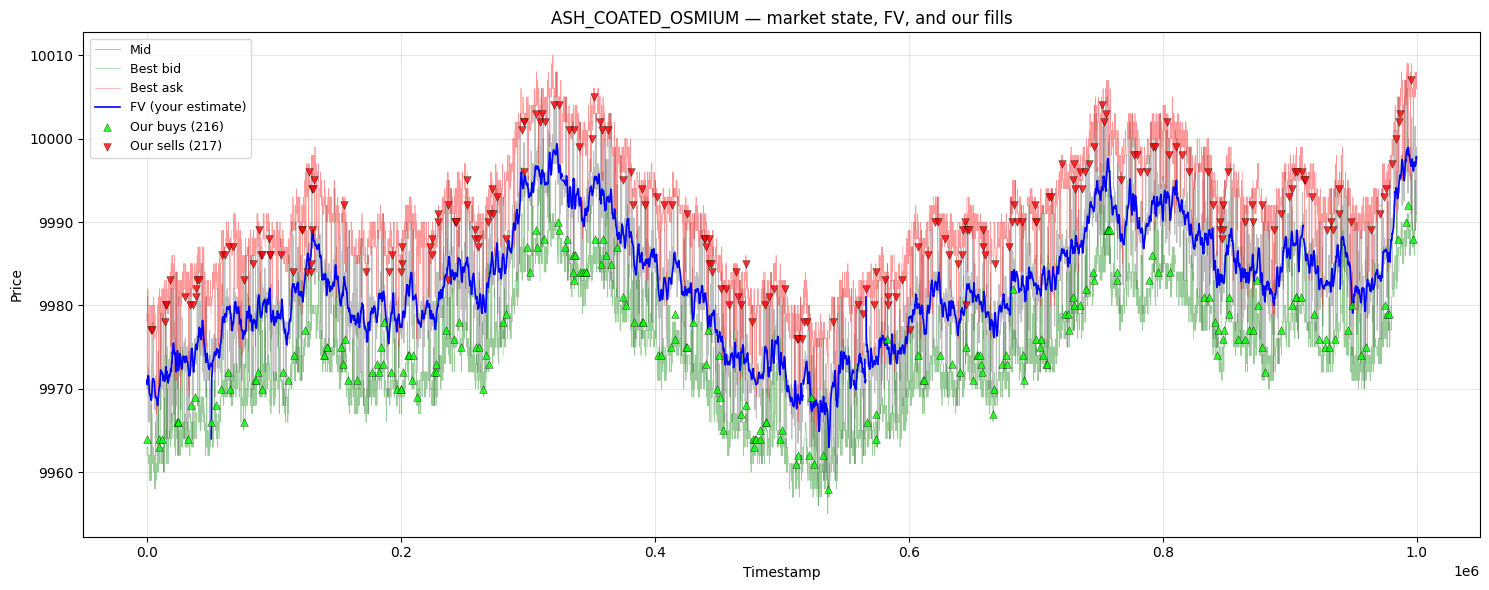

In [12]:
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(df["timestamp"], df["mid_price"].replace(0, np.nan), color="gray", alpha=0.5, linewidth=0.8, label="Mid")
ax.plot(df["timestamp"], df["best_bid"].replace(0, np.nan), color="green", alpha=0.4, linewidth=0.5, label="Best bid")
ax.plot(df["timestamp"], df["best_ask"].replace(0, np.nan), color="red", alpha=0.4, linewidth=0.5, label="Best ask")

if "FV" in df.columns:
    ax.plot(df["timestamp"], df["FV"], color="blue", linewidth=1.2, label="FV (your estimate)")

our_buys = our_trades[our_trades["kind"] == "our_buy"]
our_sells = our_trades[our_trades["kind"] == "our_sell"]
ax.scatter(our_buys["timestamp"], our_buys["price"], marker="^", color="lime",
           s=30, alpha=0.8, label=f"Our buys ({len(our_buys)})", zorder=5, edgecolors="black", linewidths=0.3)
ax.scatter(our_sells["timestamp"], our_sells["price"], marker="v", color="red",
           s=30, alpha=0.8, label=f"Our sells ({len(our_sells)})", zorder=5, edgecolors="black", linewidths=0.3)

ax.set_xlabel("Timestamp")
ax.set_ylabel("Price")
# ax.set_ylim(9980, 10020)
ax.set_title(f"{PRODUCT} \u2014 market state, FV, and our fills")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Position and PnL over time

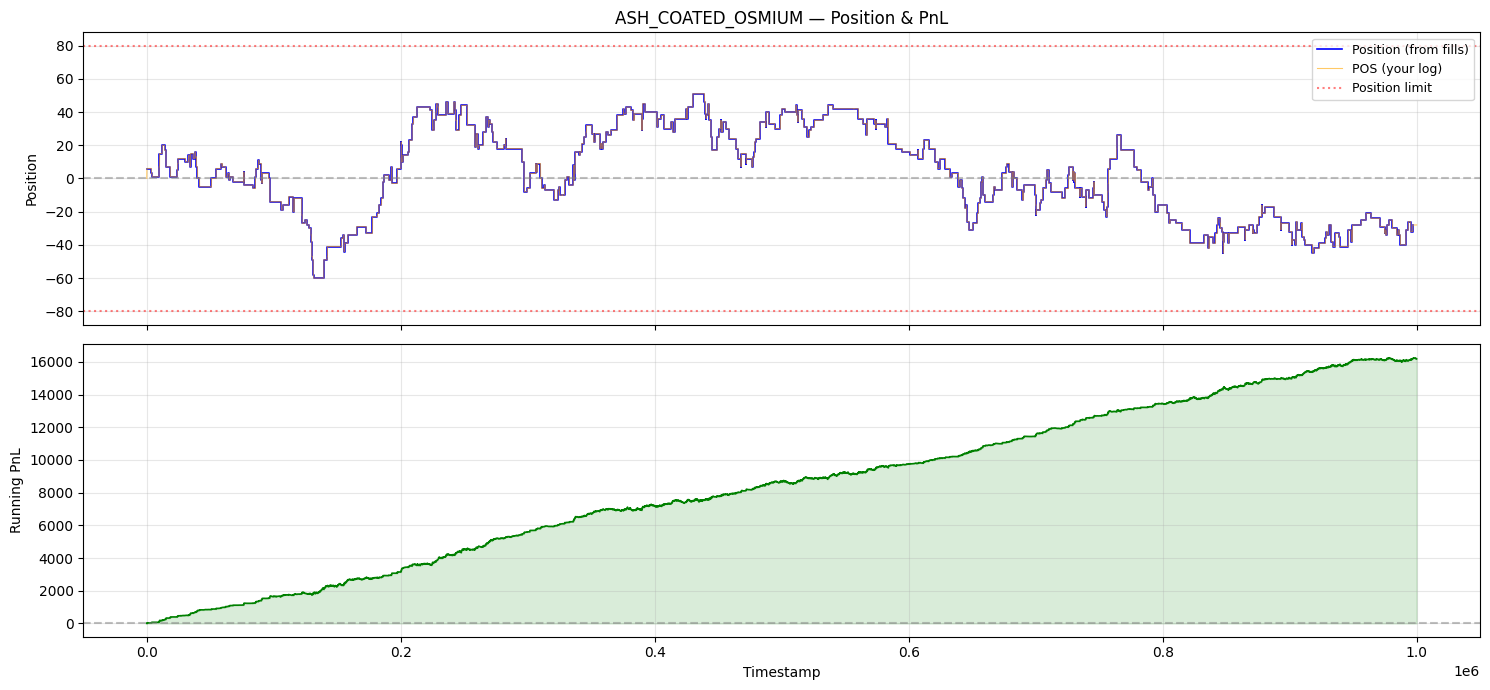

Final PnL:     16181.66
Max drawdown:  -249.12
Total trades:  433 (216 buys, 217 sells)


In [13]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 7), sharex=True, gridspec_kw={"height_ratios": [1, 1]})

our_trades_sorted = our_trades.sort_values("timestamp").copy()
our_trades_sorted["running_pos"] = our_trades_sorted["signed_qty"].cumsum()

ax1.step(our_trades_sorted["timestamp"], our_trades_sorted["running_pos"], where="post",
         color="blue", linewidth=1.2, label="Position (from fills)")
if "POS" in df.columns:
    ax1.plot(df["timestamp"], df["POS"], color="orange", alpha=0.6, linewidth=0.8, label="POS (your log)")

ax1.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax1.axhline(80, color="red", linestyle=":", alpha=0.5, label="Position limit")
ax1.axhline(-80, color="red", linestyle=":", alpha=0.5)
ax1.set_ylabel("Position")
ax1.legend(loc="best", fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_title(f"{PRODUCT} \u2014 Position & PnL")

ax2.plot(df["timestamp"], df["pnl"], color="green", linewidth=1.2)
ax2.fill_between(df["timestamp"], 0, df["pnl"], where=df["pnl"]>=0, color="green", alpha=0.15)
ax2.fill_between(df["timestamp"], 0, df["pnl"], where=df["pnl"]<0, color="red", alpha=0.15)
ax2.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax2.set_ylabel("Running PnL")
ax2.set_xlabel("Timestamp")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final PnL:     {df['pnl'].iloc[-1]:.2f}")
print(f"Max drawdown:  {(df['pnl'] - df['pnl'].cummax()).min():.2f}")
print(f"Total trades:  {len(our_trades)} ({len(our_buys)} buys, {len(our_sells)} sells)")

## 9. Fill rate analysis

For each placed order, did we get filled?

In [14]:
fill_df = df[["timestamp", "total_buy_vol", "total_sell_vol"]].copy()
if "qty_total_our_buy" in df.columns:
    fill_df["filled_buy_vol"] = df["qty_total_our_buy"]
    fill_df["filled_sell_vol"] = df["qty_total_our_sell"]
else:
    fill_df["filled_buy_vol"] = 0
    fill_df["filled_sell_vol"] = 0

fill_df["buy_fill_rate"] = np.where(fill_df["total_buy_vol"] > 0,
                                     fill_df["filled_buy_vol"] / fill_df["total_buy_vol"], np.nan)
fill_df["sell_fill_rate"] = np.where(fill_df["total_sell_vol"] > 0,
                                      fill_df["filled_sell_vol"] / fill_df["total_sell_vol"], np.nan)

total_placed_buy = fill_df['total_buy_vol'].sum()
total_placed_sell = fill_df['total_sell_vol'].sum()
total_filled_buy = fill_df['filled_buy_vol'].sum()
total_filled_sell = fill_df['filled_sell_vol'].sum()

print("Overall fill rates:")
print(f"  Buy side:  placed {total_placed_buy} units, filled {total_filled_buy} "
      f"({total_filled_buy / max(total_placed_buy, 1) * 100:.1f}%)")
print(f"  Sell side: placed {total_placed_sell} units, filled {total_filled_sell} "
      f"({total_filled_sell / max(total_placed_sell, 1) * 100:.1f}%)")

print("\nFill rate by side (per-tick avg):")
print(f"  Buy:  {fill_df['buy_fill_rate'].mean() * 100:.1f}% of placed volume per tick")
print(f"  Sell: {fill_df['sell_fill_rate'].mean() * 100:.1f}% of placed volume per tick")

Overall fill rates:
  Buy side:  placed 717758 units, filled 1110.0 (0.2%)
  Sell side: placed 794611 units, filled 1138.0 (0.1%)

Fill rate by side (per-tick avg):
  Buy:  0.2% of placed volume per tick
  Sell: 0.2% of placed volume per tick


## 10. Drill into specific ticks

Default filter: only ticks where we had fills. Edit the filter to inspect other interesting moments (position at limit, high z-score, etc).

In [15]:
interesting = df[(df.get("qty_total_our_buy", 0) > 0) | (df.get("qty_total_our_sell", 0) > 0)].copy()
interesting["buys"] = interesting["placed_buys"].apply(format_orders)
interesting["sells"] = interesting["placed_sells"].apply(format_orders)

show_cols = ["timestamp", "best_bid", "best_ask"]
if "FV" in interesting.columns: show_cols.append("FV")
if "POS" in interesting.columns: show_cols.append("POS")
show_cols += ["buys", "sells"]
if "qty_total_our_buy" in interesting.columns: show_cols += ["qty_total_our_buy", "qty_total_our_sell"]
show_cols.append("pnl")

show_cols = [c for c in show_cols if c in interesting.columns]
print(f"Ticks with fills: {len(interesting)}")
interesting[show_cols].head(50)

Ticks with fills: 429


,timestamp,best_bid,best_ask,FV,POS,buys,sells,qty_total_our_buy,qty_total_our_sell,pnl
0,0,9963.0,9979.0,9971.00,0.0,80@9964,80@9978,6.0,0.0,0.000000
36,3600,9962.0,9978.0,9968.63,6.0,74@9963,86@9977,0.0,3.0,35.332031
42,4200,9962.0,9978.0,9969.93,3.0,77@9963,83@9977,0.0,2.0,56.511719
96,9600,9962.0,9981.0,9969.77,1.0,79@9963,81@9980,6.0,0.0,71.135742
100,10000,9963.0,9981.0,9970.32,7.0,73@9964,87@9980,8.0,0.0,119.585938
121,12100,9963.0,9979.0,9971.93,15.0,65@9964,95@9978,5.0,0.0,173.781250
140,14000,9963.0,9979.0,9971.10,20.0,60@9964,100@9978,0.0,3.0,219.531250
151,15100,9964.0,NaN,9972.40,17.0,63@9965,97@9980,0.0,10.0,247.937500
185,18500,9965.0,9984.0,9971.82,7.0,73@9966,87@9983,0.0,6.0,338.421875
239,23900,9965.0,9981.0,9974.02,1.0,79@9966,81@9980,4.0,0.0,396.363281


### Other useful filters

Uncomment any of these to explore different slices:

In [16]:
# At position limit
df[df.get("POS", pd.Series(0)).abs() >= 80].head(20)

# Ticks where FV diverged from mid
if "FV" in df.columns:
    df["fv_resid"] = df["FV"] - df["mid_price"]
    df[df["fv_resid"].abs() > 2].head(20)

# Largest single-tick PnL changes (worst and best)
df["pnl_delta"] = df["pnl"].diff()
print("Biggest PnL drops:"); display(df.nsmallest(10, "pnl_delta"))
print("Biggest PnL gains:"); display(df.nlargest(10, "pnl_delta"))

# Narrow spread events (potential taking opportunities)
df[df["spread"] < 10].head(20)

Biggest PnL drops:


,timestamp,best_bid,bid_vol,best_ask,ask_vol,mid_price,pnl,POS,FV,BBID,BASK,SPREAD,placed_buys,placed_sells,n_buys_placed,n_sells_placed,total_buy_vol,total_sell_vol,price_avg_our_buy,price_avg_our_sell,qty_total_our_buy,qty_total_our_sell,spread,fv_resid,pnl_delta
3907,390700,9976.0,14.0,9992.0,14.0,9984.0,7098.46875,45.0,9984.41,9976.0,9992.0,16.0,[],"[{'p': 9991, 'v': 125}]",0,1,0,125,NaN,NaN,0.0,0.0,16.0,0.41,-48.90625
4338,433800,9970.0,30.0,9989.0,10.0,9979.5,7523.75000,51.0,9981.84,9970.0,9989.0,19.0,[],"[{'p': 9988, 'v': 131}]",0,1,0,131,NaN,NaN,0.0,0.0,19.0,2.34,-48.06250
4375,437500,9972.0,12.0,9988.0,12.0,9980.0,7487.37500,51.0,9982.36,9972.0,9988.0,16.0,[],"[{'p': 9987, 'v': 131}]",0,1,0,131,NaN,NaN,0.0,0.0,16.0,2.36,-44.87500
2149,214900,9970.0,15.0,9986.0,15.0,9978.0,3563.34375,43.0,9977.84,9970.0,9986.0,16.0,[],"[{'p': 9985, 'v': 123}]",0,1,0,123,NaN,NaN,0.0,0.0,16.0,-0.16,-39.93750
8483,848300,9976.0,11.0,9994.0,27.0,9985.0,14410.50000,-38.0,9982.72,9976.0,9994.0,18.0,"[{'p': 9977, 'v': 118}]","[{'p': 9993, 'v': 42}]",1,1,118,42,9977.0,0.0,5.0,0.0,18.0,-2.28,-39.43750
1394,139400,9973.0,25.0,9992.0,15.0,9982.5,2078.81250,-60.0,9983.26,9973.0,9992.0,19.0,"[{'p': 9974, 'v': 140}]",[],1,0,140,0,9974.0,0.0,11.0,0.0,19.0,0.76,-38.56250
8400,840000,9977.0,15.0,9993.0,15.0,9985.0,14054.37500,-39.0,9985.89,9977.0,9993.0,16.0,"[{'p': 9978, 'v': 119}]","[{'p': 9992, 'v': 41}]",1,1,119,41,NaN,NaN,0.0,0.0,16.0,0.89,-37.21875
8223,822300,9978.0,23.0,9997.0,15.0,9987.5,13746.68750,-39.0,9989.71,9978.0,9997.0,19.0,"[{'p': 9979, 'v': 119}]","[{'p': 9996, 'v': 41}]",1,1,119,41,NaN,NaN,0.0,0.0,19.0,2.21,-36.21875
8254,825400,9980.0,11.0,9996.0,11.0,9988.0,13775.71875,-39.0,9987.09,9980.0,9996.0,16.0,"[{'p': 9981, 'v': 119}]","[{'p': 9995, 'v': 41}]",1,1,119,41,NaN,NaN,0.0,0.0,16.0,-0.91,-36.21875
1323,132300,9979.0,10.0,9995.0,10.0,9987.0,1869.68750,-60.0,9987.60,9979.0,9995.0,16.0,"[{'p': 9980, 'v': 140}]",[],1,0,140,0,NaN,NaN,0.0,0.0,16.0,0.60,-36.12500


Biggest PnL gains:


,timestamp,best_bid,bid_vol,best_ask,ask_vol,mid_price,pnl,POS,FV,BBID,BASK,SPREAD,placed_buys,placed_sells,n_buys_placed,n_sells_placed,total_buy_vol,total_sell_vol,price_avg_our_buy,price_avg_our_sell,qty_total_our_buy,qty_total_our_sell,spread,fv_resid,pnl_delta
3899,389900,9977.0,12.0,9993.0,12.0,9985.0,7027.437500,29.0,9985.88,9977.0,9993.0,16.0,"[{'p': 9978, 'v': 51}]","[{'p': 9992, 'v': 109}]",1,1,51,109,9978.0,0.0,7.0,0.0,16.0,0.88,107.625000
1395,139500,9973.0,26.0,9992.0,14.0,9982.5,2185.187500,-49.0,9983.11,9973.0,9992.0,19.0,"[{'p': 9974, 'v': 129}]",[],1,0,129,0,NaN,NaN,0.0,0.0,19.0,0.61,106.375000
970,97000,9971.0,10.0,9986.0,10.0,9978.5,1660.781250,-14.0,9981.84,9971.0,9986.0,15.0,"[{'p': 9972, 'v': 94}]","[{'p': 9985, 'v': 66}]",1,1,94,66,NaN,NaN,0.0,0.0,15.0,3.34,104.781250
2090,209000,9973.0,12.0,9982.0,5.0,9977.5,3596.281250,33.0,9982.62,9973.0,9982.0,9.0,"[{'p': 9974, 'v': 47}]","[{'p': 9988, 'v': 113}]",1,1,47,113,NaN,NaN,0.0,0.0,9.0,5.12,97.187500
1554,155400,9975.0,15.0,9991.0,15.0,9983.0,2457.843750,-44.0,9983.31,9975.0,9991.0,16.0,"[{'p': 9976, 'v': 124}]",[],1,0,124,0,NaN,NaN,0.0,0.0,16.0,0.31,96.843750
3017,301700,9986.0,14.0,10002.0,14.0,9994.0,5686.609375,3.0,9993.32,9986.0,10002.0,16.0,"[{'p': 9987, 'v': 77}]","[{'p': 10001, 'v': 83}]",1,1,77,83,NaN,NaN,0.0,0.0,16.0,-0.68,86.734375
5674,567400,9963.0,30.0,9984.0,30.0,9973.5,9411.968750,36.0,9974.41,9963.0,9984.0,21.0,"[{'p': 9964, 'v': 44}]","[{'p': 9983, 'v': 116}]",1,1,44,116,NaN,NaN,0.0,0.0,21.0,0.91,85.109375
1974,197400,9971.0,14.0,9987.0,14.0,9979.0,3153.820312,6.0,9977.91,9971.0,9987.0,16.0,"[{'p': 9972, 'v': 74}]","[{'p': 9986, 'v': 86}]",1,1,74,86,NaN,NaN,0.0,0.0,16.0,-1.09,84.126953
152,15200,9964.0,10.0,9980.0,10.0,9972.0,327.625000,7.0,9972.20,9964.0,9980.0,16.0,"[{'p': 9965, 'v': 73}]","[{'p': 9979, 'v': 87}]",1,1,73,87,NaN,NaN,0.0,0.0,16.0,0.20,79.687500
4443,444300,9970.0,12.0,9988.0,21.0,9979.0,7713.265625,25.0,9977.94,9970.0,9988.0,18.0,"[{'p': 9971, 'v': 55}]","[{'p': 9987, 'v': 105}]",1,1,55,105,NaN,NaN,0.0,0.0,18.0,-1.06,79.515625


,timestamp,best_bid,bid_vol,best_ask,ask_vol,mid_price,pnl,POS,FV,BBID,BASK,SPREAD,placed_buys,placed_sells,n_buys_placed,n_sells_placed,total_buy_vol,total_sell_vol,price_avg_our_buy,price_avg_our_sell,qty_total_our_buy,qty_total_our_sell,spread,fv_resid,pnl_delta
76,7600,9961.0,14.0,9967.0,5.0,9964.0,70.177734,1.0,9968.89,9961.0,9967.0,6.0,"[{'p': 9962, 'v': 79}]","[{'p': 9979, 'v': 81}]",1,1,79,81,NaN,NaN,0.0,0.0,6.0,4.89,0.332031
94,9400,9960.0,30.0,9968.0,10.0,9964.0,71.429688,1.0,9969.59,9960.0,9968.0,8.0,"[{'p': 9961, 'v': 79}]","[{'p': 9980, 'v': 81}]",1,1,79,81,NaN,NaN,0.0,0.0,8.0,5.59,0.048828
107,10700,9972.0,5.0,9979.0,13.0,9975.5,170.359375,15.0,9971.74,9972.0,9979.0,7.0,"[{'p': 9964, 'v': 65}]","[{'p': 9978, 'v': 95}]",1,1,65,95,NaN,NaN,0.0,0.0,7.0,-3.76,-4.421875
110,11000,9963.0,11.0,9972.0,5.0,9967.5,172.203125,15.0,9972.21,9963.0,9972.0,9.0,"[{'p': 9964, 'v': 65}]","[{'p': 9978, 'v': 95}]",1,1,65,95,NaN,NaN,0.0,0.0,9.0,4.71,3.234375
145,14500,9965.0,10.0,9974.0,5.0,9969.5,257.781250,17.0,9971.44,9965.0,9974.0,9.0,"[{'p': 9966, 'v': 63}]","[{'p': 9973, 'v': 97}]",1,1,63,97,NaN,NaN,0.0,0.0,9.0,1.94,3.453125
150,15000,9964.0,13.0,9973.0,3.0,9968.5,245.968750,17.0,9972.65,9964.0,9973.0,9.0,"[{'p': 9965, 'v': 63}]","[{'p': 9979, 'v': 97}]",1,1,63,97,NaN,NaN,0.0,0.0,9.0,4.15,-4.859375
155,15500,9974.0,10.0,9983.0,22.0,9978.5,331.476562,7.0,9972.03,9974.0,9983.0,9.0,"[{'p': 9965, 'v': 73}]","[{'p': 9982, 'v': 87}]",1,1,73,87,NaN,NaN,0.0,0.0,9.0,-6.47,5.484375
198,19800,9964.0,29.0,9972.0,4.0,9968.0,397.828125,1.0,9973.21,9964.0,9972.0,8.0,"[{'p': 9965, 'v': 79}]","[{'p': 9982, 'v': 81}]",1,1,79,81,NaN,NaN,0.0,0.0,8.0,5.21,0.250977
212,21200,9967.0,12.0,9976.0,5.0,9971.5,397.598633,1.0,9975.01,9967.0,9976.0,9.0,[],"[{'p': 9975, 'v': 81}]",0,1,0,81,NaN,NaN,0.0,0.0,9.0,3.51,-0.263672
223,22300,9963.0,28.0,9971.0,4.0,9967.0,396.420898,1.0,9974.19,9963.0,9971.0,8.0,"[{'p': 9964, 'v': 79}]","[{'p': 9980, 'v': 81}]",1,1,79,81,NaN,NaN,0.0,0.0,8.0,7.19,-0.013672
